# GNNExplainer — AML Typology Mapping (Elliptic Dataset)

In [26]:
!pip install pyspark torch-geometric -q

In [27]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import networkx as nx

import torch
import torch.nn as nn
import torch.nn.functional as F

from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when

from sklearn.metrics import f1_score, classification_report

from torch_geometric.data import Data
from torch_geometric.nn import GATConv
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig

## Load Data

In [28]:
spark = SparkSession.builder.appName("EllipticFraud").getOrCreate()

features_path = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_features.csv"
classes_path  = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_classes.csv"
edges_path    = "/kaggle/input/datasets/organizations/ellipticco/elliptic-data-set/elliptic_bitcoin_dataset/elliptic_txs_edgelist.csv"

features_sdf = spark.read.csv(features_path, inferSchema=True, header=False)
classes_sdf  = spark.read.csv(classes_path,  inferSchema=True, header=True)
edges_sdf    = spark.read.csv(edges_path,    inferSchema=True, header=True)

feature_columns = ["txId", "time_step"] + [f"f_{i}" for i in range(features_sdf.count() - 2)]
feature_columns = ["txId", "time_step"] + [f"f_{i}" for i in range(len(features_sdf.columns) - 2)]
features_sdf = features_sdf.toDF(*feature_columns)

merged_sdf = features_sdf.join(classes_sdf, on="txId", how="inner")
merged_sdf = merged_sdf.filter(col("class") != "unknown")
merged_sdf = merged_sdf.withColumn("class", when(col("class") == "1", 1).otherwise(0))

df = merged_sdf.toPandas()
print(f"Labelled transactions: {len(df)} | Illicit: {df['class'].sum()} | Licit: {(df['class']==0).sum()}")

Labelled transactions: 46564 | Illicit: 4545 | Licit: 42019


## Temporal Split & Graph Construction

In [29]:
node_ids = df["txId"].unique()
id_map   = {nid: idx for idx, nid in enumerate(node_ids)}
df["node_idx"] = df["txId"].map(id_map)

all_feature_cols   = [c for c in df.columns if c.startswith("f_")]   # 165 features
local_feature_cols = all_feature_cols[:93]                            # first 94 (index 0 = time_step)

X_af = df[all_feature_cols].values.astype(np.float32)
X_lf = df[local_feature_cols].values.astype(np.float32)
y_np = df["class"].astype(int).values
ts   = df["time_step"].values

train_idx = np.where(ts <= 34)[0]
test_idx  = np.where(ts  > 34)[0]

print(f"Train size: {len(train_idx)} | Test size: {len(test_idx)}")
print(f"Train illicit: {y_np[train_idx].sum()} | Test illicit: {y_np[test_idx].sum()}")

Train size: 29894 | Test size: 16670
Train illicit: 3462 | Test illicit: 1083


In [30]:
edges_pd = edges_sdf.toPandas()
edges_pd = edges_pd[edges_pd["txId1"].isin(id_map) & edges_pd["txId2"].isin(id_map)]

source = edges_pd["txId1"].map(id_map).values
target = edges_pd["txId2"].map(id_map).values
edge_index = torch.tensor(np.array([source, target]), dtype=torch.long)

X_af_t = torch.tensor(X_af, dtype=torch.float)
y_t    = torch.tensor(y_np, dtype=torch.long)

data = Data(x=X_af_t, edge_index=edge_index, y=y_t)

train_mask = torch.zeros(data.num_nodes, dtype=torch.bool)
test_mask  = torch.zeros(data.num_nodes, dtype=torch.bool)
train_mask[train_idx] = True
test_mask[test_idx]   = True
data.train_mask = train_mask
data.test_mask  = test_mask

print(data)

Data(x=[46564, 165], edge_index=[2, 36624], y=[46564], train_mask=[46564], test_mask=[46564])


## Model Definitions

In [31]:
class FocalLoss(nn.Module):
    def __init__(self, alpha=0.75, gamma=2):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma

    def forward(self, inputs, targets):
        ce_loss = F.cross_entropy(inputs, targets, reduction="none")
        pt = torch.exp(-ce_loss)
        return (self.alpha * (1 - pt) ** self.gamma * ce_loss).mean()

In [32]:
class GATModel(nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels):
        super().__init__()
        self.conv1 = GATConv(in_channels, hidden_channels, heads=4)
        self.conv2 = GATConv(hidden_channels * 4, hidden_channels)
        self.lin   = nn.Linear(hidden_channels, out_channels)

    def forward(self, x, edge_index):
        x = F.elu(self.conv1(x, edge_index))
        x = F.dropout(x, p=0.3, training=self.training)
        embeddings = self.conv2(x, edge_index)
        out = self.lin(F.elu(embeddings))
        return out, embeddings


class GATModelWrapper(nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model

    def forward(self, x, edge_index):
        out, _ = self.model(x, edge_index)
        return out

## Train GAT

In [33]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = GATModel(
    in_channels=data.num_node_features,
    hidden_channels=128,
    out_channels=2
).to(device)

data = data.to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
criterion = FocalLoss()
scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=100, gamma=0.5)

def train_step():
    model.train()
    optimizer.zero_grad()
    out, _ = model(data.x, data.edge_index)
    loss = criterion(out[data.train_mask], data.y[data.train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

for epoch in range(1, 401):
    loss = train_step()
    scheduler.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss:.4f}")

Epoch 020 | Loss: 0.0346
Epoch 040 | Loss: 0.0280
Epoch 060 | Loss: 0.0248
Epoch 080 | Loss: 0.0228
Epoch 100 | Loss: 0.0213
Epoch 120 | Loss: 0.0205
Epoch 140 | Loss: 0.0200
Epoch 160 | Loss: 0.0193
Epoch 180 | Loss: 0.0189
Epoch 200 | Loss: 0.0185
Epoch 220 | Loss: 0.0182
Epoch 240 | Loss: 0.0181
Epoch 260 | Loss: 0.0178
Epoch 280 | Loss: 0.0175
Epoch 300 | Loss: 0.0173
Epoch 320 | Loss: 0.0176
Epoch 340 | Loss: 0.0172
Epoch 360 | Loss: 0.0169
Epoch 380 | Loss: 0.0170
Epoch 400 | Loss: 0.0171


## Evaluate GAT

In [34]:
def report(name, y_true, y_pred):
    print(f"\n{'='*50}")
    print(f"{name}")
    print(classification_report(y_true, y_pred, target_names=["licit", "illicit"], digits=3))
    return f1_score(y_true, y_pred, pos_label=1)


model.eval()
with torch.no_grad():
    out, embeddings = model(data.x, data.edge_index)
    preds = out.argmax(dim=1)

test_preds  = preds[data.test_mask].cpu().numpy()
test_labels = data.y[data.test_mask].cpu().numpy()
embeddings_np = embeddings.cpu().numpy()

report("GAT", test_labels, test_preds)


GAT
              precision    recall  f1-score   support

       licit      0.973     0.950     0.962     15587
     illicit      0.468     0.626     0.535      1083

    accuracy                          0.929     16670
   macro avg      0.720     0.788     0.749     16670
weighted avg      0.941     0.929     0.934     16670



0.5353335965258587

## GNNExplainer — AML Typology Mapping

Generating explanations for illicit transactions...
  Node 29897 | True: Illicit | Pred: Illicit | Typology: Structuring
  Node 29898 | True: Illicit | Pred: Illicit | Typology: Structuring
  Node 29912 | True: Illicit | Pred: Illicit | Typology: Fan-in
  Node 29930 | True: Illicit | Pred: Illicit | Typology: Structuring
  Node 29935 | True: Illicit | Pred: Illicit | Typology: Structuring

Generating explanations for licit transactions...
  Node 29894 | True: Licit | Pred: Licit | Typology: Structuring
  Node 29895 | True: Licit | Pred: Licit | Typology: Structuring
  Node 29896 | True: Licit | Pred: Licit | Typology: Structuring


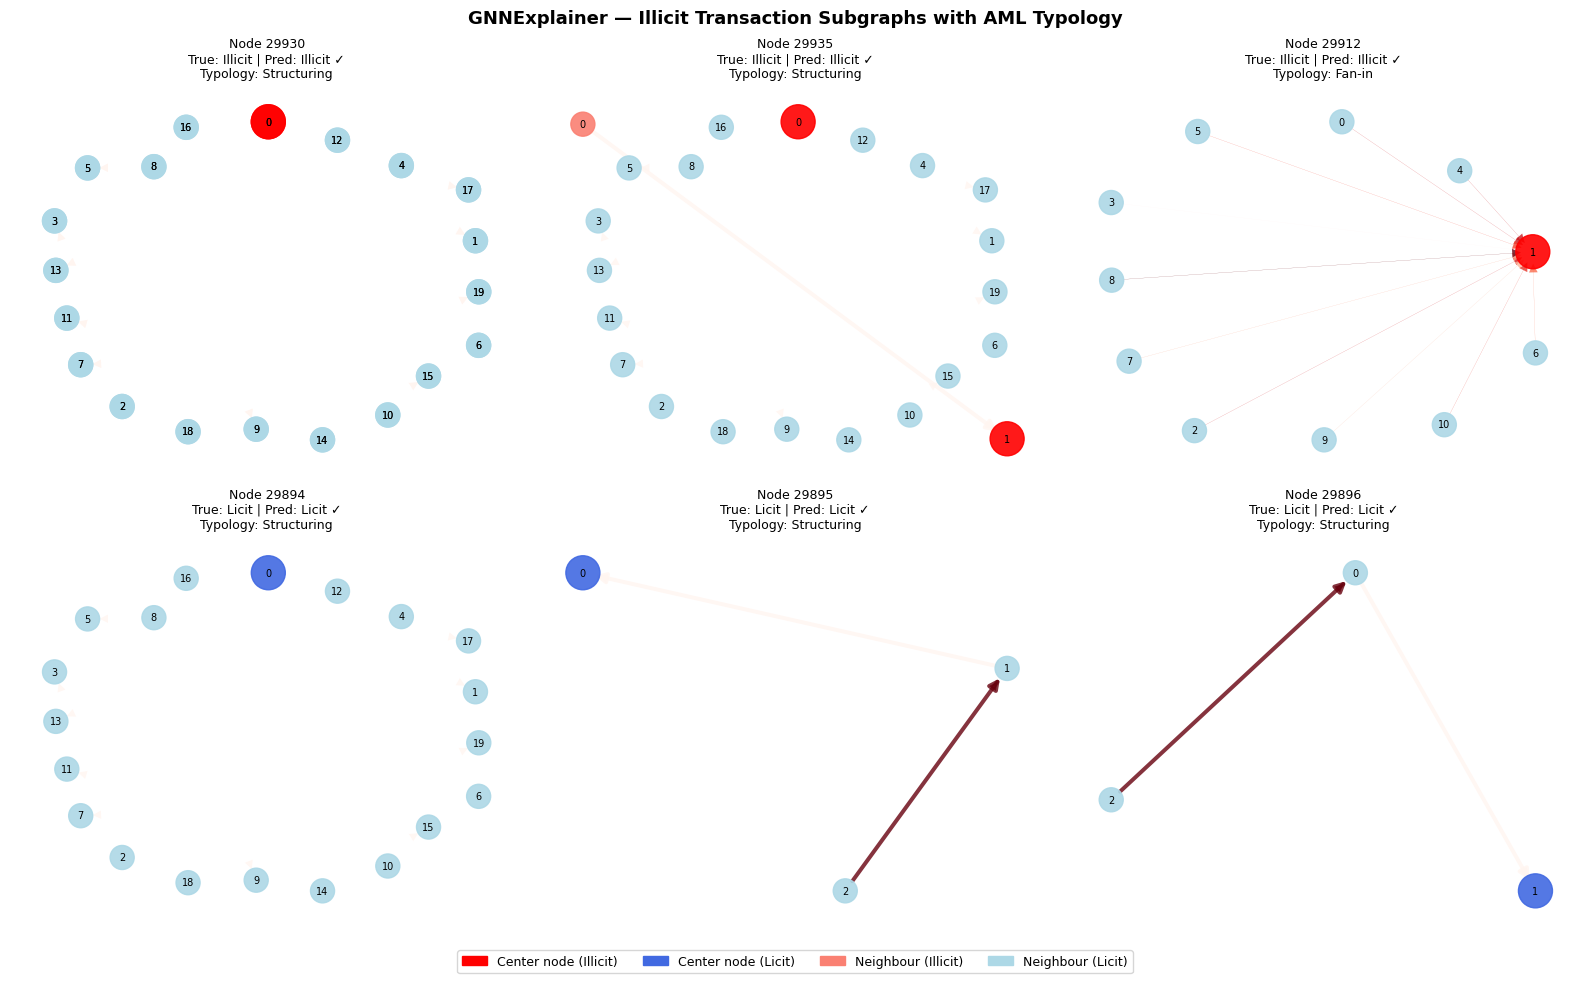


AML Typology Distribution (Illicit nodes):
  Structuring: 4 — Breaking large amounts into smaller transactions to avoid detection
  Fan-in: 1 — Many inputs consolidating into a single illicit destination


In [35]:
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig
import matplotlib.patches as mpatches
import networkx as nx

class GATModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x, edge_index):
        out, _ = self.model(x, edge_index)
        return out

wrapped_model = GATModelWrapper(model).to(device)
wrapped_model.eval()

AML_TYPOLOGIES = {
    "Layering":    "Multiple hops moving funds through intermediaries to obscure origin",
    "Structuring": "Breaking large amounts into smaller transactions to avoid detection",
    "Fan-out":     "Single illicit source distributing to many outputs simultaneously",
    "Fan-in":      "Many inputs consolidating into a single illicit destination",
    "Pass-through":"Rapid movement with minimal holding — funds in and out quickly",
}

explainer = Explainer(
    model=wrapped_model,
    algorithm=GNNExplainer(epochs=300),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=ModelConfig(
        mode="multiclass_classification",
        task_level="node",
        return_type="raw",
    ),
)

test_node_indices  = data.test_mask.nonzero(as_tuple=True)[0]
illicit_test_nodes = test_node_indices[data.y[test_node_indices] == 1]
licit_test_nodes   = test_node_indices[data.y[test_node_indices] == 0]

illicit_samples = illicit_test_nodes[:5].tolist()
licit_samples   = licit_test_nodes[:3].tolist()

def classify_subgraph_typology(edge_index_sub, node_labels, center_idx):
    if edge_index_sub.shape[1] == 0:
        return "Insufficient edges"
    out_edges = (edge_index_sub[0] == center_idx).sum().item()
    in_edges  = (edge_index_sub[1] == center_idx).sum().item()
    n_nodes   = node_labels.shape[0]
    if out_edges >= 3 and in_edges <= 1:
        return "Fan-out"
    elif in_edges >= 3 and out_edges <= 1:
        return "Fan-in"
    elif n_nodes >= 4 and out_edges >= 1 and in_edges >= 1:
        return "Layering"
    elif out_edges == 1 and in_edges == 1:
        return "Pass-through"
    else:
        return "Structuring"

def plot_explanation_subgraph(explanation, node_idx, true_label, pred_label, ax):
    edge_mask      = explanation.edge_mask
    node_feat_mask = explanation.node_mask
    sig_edges = (edge_mask > 0.3).nonzero(as_tuple=True)[0]
    if sig_edges.shape[0] == 0:
        sig_edges = edge_mask.topk(min(10, edge_mask.shape[0])).indices
    sub_edge_index = explanation.edge_index[:, sig_edges]
    involved_nodes = sub_edge_index.unique()
    node_map       = {n.item(): i for i, n in enumerate(involved_nodes)}
    center_local   = node_map.get(node_idx, 0)
    G = nx.DiGraph()
    for n in involved_nodes.tolist():
        G.add_node(node_map[n])
    for e in range(sub_edge_index.shape[1]):
        src = node_map.get(sub_edge_index[0, e].item())
        dst = node_map.get(sub_edge_index[1, e].item())
        if src is not None and dst is not None:
            G.add_edge(src, dst, weight=edge_mask[sig_edges[e]].item())
    typology = classify_subgraph_typology(
        sub_edge_index - sub_edge_index.min(),
        node_feat_mask,
        center_local
    )
    pos         = nx.spring_layout(G, seed=42, k=2)
    node_colors = []
    node_sizes  = []
    for n in G.nodes():
        if n == center_local:
            node_colors.append("red" if true_label == 1 else "royalblue")
            node_sizes.append(600)
        else:
            orig_idx = involved_nodes[n].item() if n < len(involved_nodes) else -1
            label    = data.y[orig_idx].item() if 0 <= orig_idx < data.y.shape[0] else 0
            node_colors.append("salmon" if label == 1 else "lightblue")
            node_sizes.append(300)
    edge_weights = [G[u][v]["weight"] for u, v in G.edges()]
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, node_size=node_sizes, ax=ax, alpha=0.9)
    nx.draw_networkx_edges(G, pos, width=[w * 3 for w in edge_weights],
                           edge_color=edge_weights, edge_cmap=plt.cm.Reds,
                           ax=ax, arrows=True, arrowsize=15, alpha=0.8)
    nx.draw_networkx_labels(G, pos, ax=ax, font_size=7)
    pred_str = "Illicit" if pred_label == 1 else "Licit"
    true_str = "Illicit" if true_label == 1 else "Licit"
    correct  = "✓" if pred_label == true_label else "✗"
    ax.set_title(
        f"Node {node_idx}\nTrue: {true_str} | Pred: {pred_str} {correct}\nTypology: {typology}",
        fontsize=9, pad=8
    )
    ax.axis("off")
    return typology

with torch.no_grad():
    out_all, _ = model(data.x, data.edge_index)
all_preds = out_all.argmax(dim=1)

print("Generating explanations for illicit transactions...")
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("GNNExplainer — Illicit Transaction Subgraphs with AML Typology", fontsize=13, fontweight="bold")

typology_counts = {}

for i, node_idx in enumerate(illicit_samples):
    explanation = explainer(data.x, data.edge_index, index=node_idx)
    true_label  = data.y[node_idx].item()
    pred_label  = all_preds[node_idx].item()
    typology    = plot_explanation_subgraph(explanation, node_idx, true_label, pred_label, axes[0, i % 3])
    typology_counts[typology] = typology_counts.get(typology, 0) + 1
    print(f"  Node {node_idx} | True: {'Illicit' if true_label==1 else 'Licit'} | Pred: {'Illicit' if pred_label==1 else 'Licit'} | Typology: {typology}")

print("\nGenerating explanations for licit transactions...")
for i, node_idx in enumerate(licit_samples):
    explanation = explainer(data.x, data.edge_index, index=node_idx)
    true_label  = data.y[node_idx].item()
    pred_label  = all_preds[node_idx].item()
    typology    = plot_explanation_subgraph(explanation, node_idx, true_label, pred_label, axes[1, i % 3])
    print(f"  Node {node_idx} | True: {'Illicit' if true_label==1 else 'Licit'} | Pred: {'Illicit' if pred_label==1 else 'Licit'} | Typology: {typology}")

legend_elements = [
    mpatches.Patch(color="red",       label="Center node (Illicit)"),
    mpatches.Patch(color="royalblue", label="Center node (Licit)"),
    mpatches.Patch(color="salmon",    label="Neighbour (Illicit)"),
    mpatches.Patch(color="lightblue", label="Neighbour (Licit)"),
]
fig.legend(handles=legend_elements, loc="lower center", ncol=4, fontsize=9, bbox_to_anchor=(0.5, 0.01))
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

print("\nAML Typology Distribution (Illicit nodes):")
for t, count in typology_counts.items():
    print(f"  {t}: {count} — {AML_TYPOLOGIES[t]}")


## GNNExplainer — Feature Importance (Graph-Aware)

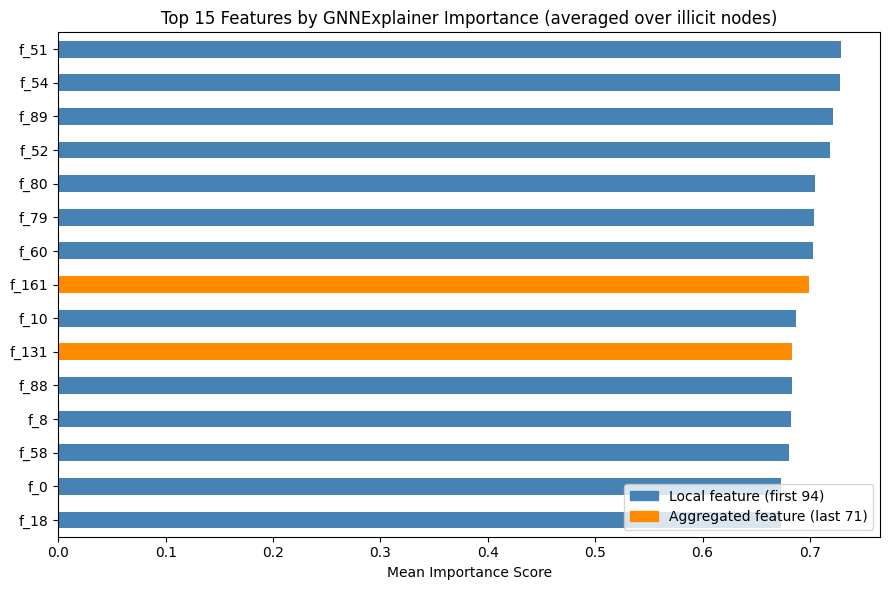

Top 15 GNNExplainer breakdown — Local: 13 | Aggregated: 2
Compare with RF importance   — Local: 18 | Aggregated: 2


In [36]:
from torch_geometric.explain import Explainer, GNNExplainer
from torch_geometric.explain.config import ModelConfig

class GATModelWrapper(torch.nn.Module):
    def __init__(self, model):
        super().__init__()
        self.model = model
    def forward(self, x, edge_index):
        out, _ = self.model(x, edge_index)
        return out

wrapped_model_feat = GATModelWrapper(model).to(device)
wrapped_model_feat.eval()

feat_explainer = Explainer(
    model=wrapped_model_feat,
    algorithm=GNNExplainer(epochs=200),
    explanation_type="model",
    node_mask_type="attributes",
    edge_mask_type="object",
    model_config=ModelConfig(
        mode="multiclass_classification",
        task_level="node",
        return_type="raw",
    ),
)

test_node_indices  = data.test_mask.nonzero(as_tuple=True)[0]
illicit_test_nodes = test_node_indices[data.y[test_node_indices] == 1]
sample_nodes       = illicit_test_nodes[:30].tolist()

all_node_masks = []
for node_idx in sample_nodes:
    try:
        exp = feat_explainer(data.x, data.edge_index, index=node_idx)
        all_node_masks.append(exp.node_mask[node_idx].cpu().numpy())
    except Exception as e:
        print(f"Skipped node {node_idx}: {e}")

mean_importance = np.array(all_node_masks).mean(axis=0)
feat_imp_series = pd.Series(mean_importance, index=all_feature_cols)
top15 = feat_imp_series.nlargest(15)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ["steelblue" if c in local_feature_cols else "darkorange" for c in top15.index]
top15.sort_values().plot(kind="barh", ax=ax, color=list(reversed(colors)))

from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color="steelblue",   label="Local feature (first 94)"),
    Patch(color="darkorange",  label="Aggregated feature (last 71)")
], loc="lower right")

ax.set_title("Top 15 Features by GNNExplainer Importance (averaged over illicit nodes)")
ax.set_xlabel("Mean Importance Score")
plt.tight_layout()
plt.show()

local_count = sum(c in local_feature_cols for c in top15.index)
agg_count   = sum(c not in local_feature_cols for c in top15.index)
print(f"Top 15 GNNExplainer breakdown — Local: {local_count} | Aggregated: {agg_count}")
print(f"Compare with RF importance   — Local: 18 | Aggregated: 2")


In [37]:
import zipfile
import joblib

os.makedirs("saved_models", exist_ok=True)

torch.save(model.state_dict(), "saved_models/gat_model.pth")

zip_path = "gnnexplainer_models.zip"
with zipfile.ZipFile(zip_path, "w") as zf:
    for root, _, files in os.walk("saved_models"):
        for f in files:
            zf.write(os.path.join(root, f), arcname=f)

print("Saved:", zip_path)

Saved: gnnexplainer_models.zip
